In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('tetouancity.csv')

# Quick look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (52416, 9)

First 5 rows:


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
print("=== Column Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  object 
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB
None

=== Missing Values ===
DateTime                     0
Temperature                  0
Humidity                     0
Wind Speed                   0
general diffuse flows        0
diffuse flows       

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [5]:
# The dataset has a 'Datetime' column — parse it properly
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.set_index('DateTime')
df = df.sort_index()

print("Date range:", df.index.min(), "→", df.index.max())
print("Total records:", len(df))
df.head()

Date range: 2017-01-01 00:00:00 → 2017-12-30 23:50:00
Total records: 52416


,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


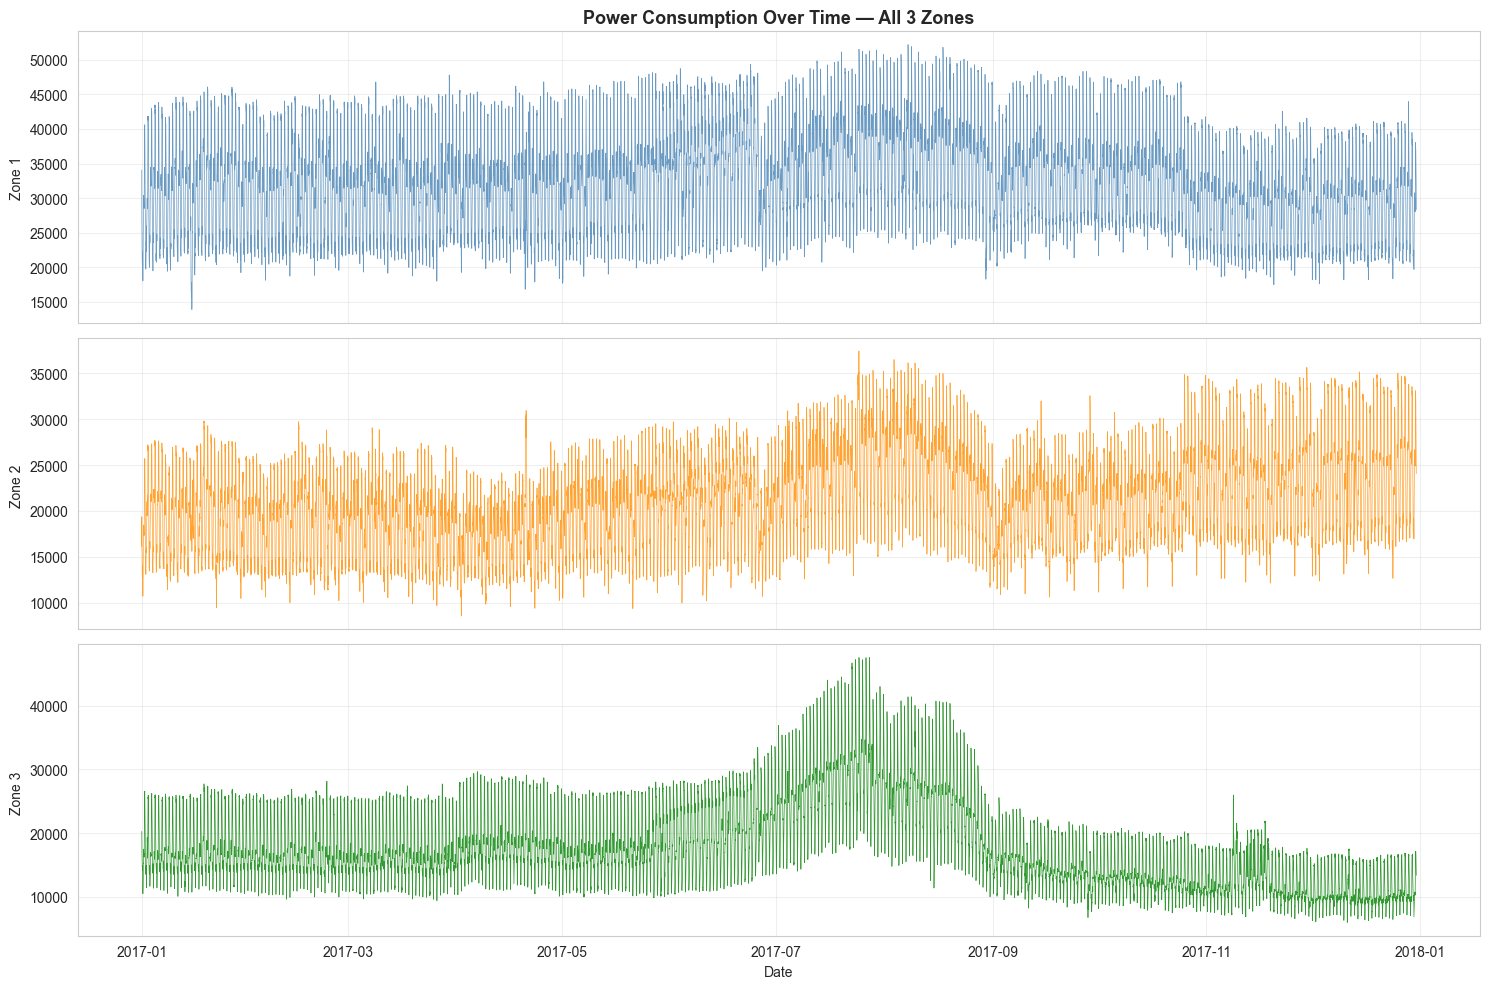

✅ Plot saved!


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

zones = ['Zone 1 Power Consumption', 'Zone 2  Power Consumption', 'Zone 3  Power Consumption']
colors = ['steelblue', 'darkorange', 'green']

for i, (zone, color) in enumerate(zip(zones, colors)):
    axes[i].plot(df.index, df[zone], color=color, linewidth=0.5, alpha=0.8)
    axes[i].set_ylabel(zone.replace(' Power Consumption', ''), fontsize=10)

axes[0].set_title('Power Consumption Over Time — All 3 Zones', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('plot1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

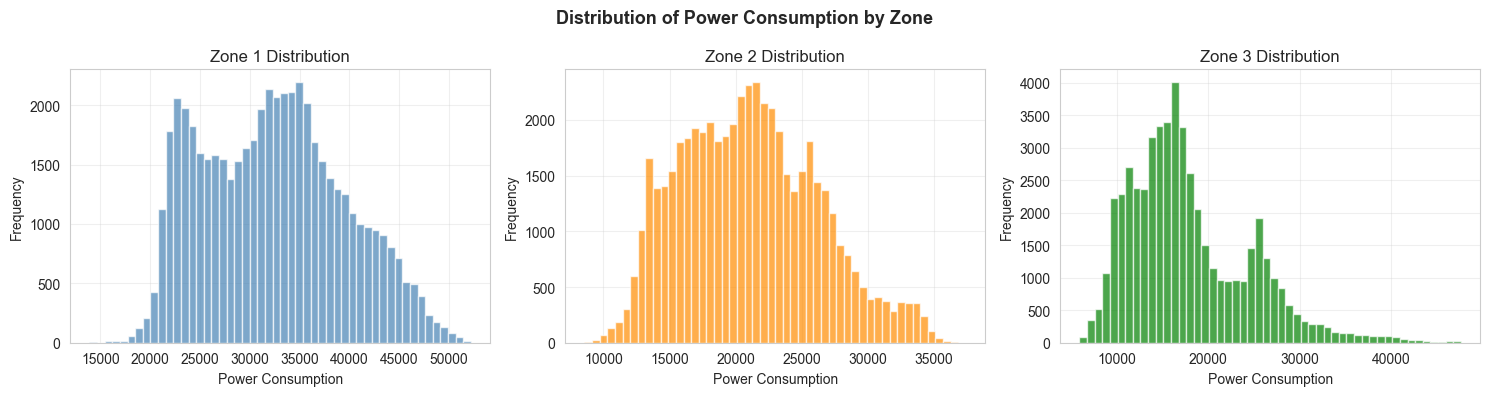

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (zone, color) in enumerate(zip(zones, colors)):
    axes[i].hist(df[zone], bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{zone.split()[0]} {zone.split()[1]} Distribution')
    axes[i].set_xlabel('Power Consumption')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Power Consumption by Zone', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

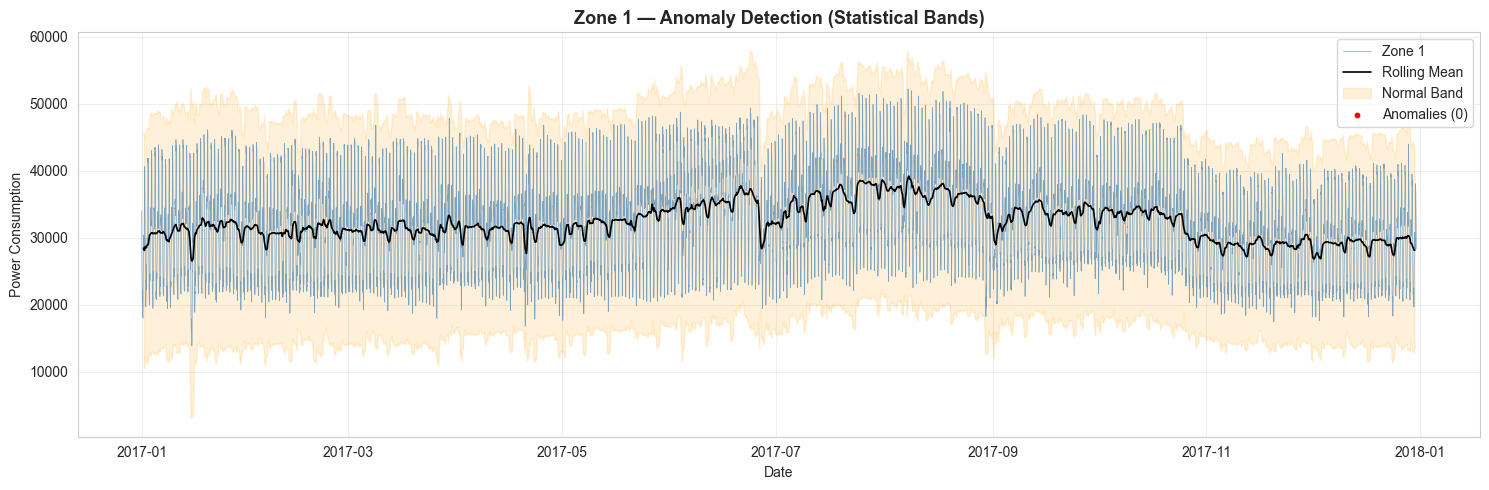

🔴 Total anomaly points detected: 0
📊 That's 0.00% of all data


In [8]:
# Use Zone 1 as our primary signal
zone1 = df['Zone 1 Power Consumption']

# Rolling average over 24 hours (10-min intervals → 144 points per day)
rolling_mean = zone1.rolling(window=144, center=True).mean()
rolling_std  = zone1.rolling(window=144, center=True).std()

# Define anomaly = value more than 2.5 std away from rolling mean
upper_bound = rolling_mean + 2.5 * rolling_std
lower_bound = rolling_mean - 2.5 * rolling_std
anomalies = df[(zone1 < lower_bound) | (zone1 > upper_bound)]

plt.figure(figsize=(15, 5))
plt.plot(df.index, zone1, color='steelblue', linewidth=0.5, alpha=0.7, label='Zone 1')
plt.plot(df.index, rolling_mean, color='black', linewidth=1.2, label='Rolling Mean')
plt.fill_between(df.index, lower_bound, upper_bound, alpha=0.15, color='orange', label='Normal Band')
plt.scatter(anomalies.index, anomalies['Zone 1 Power Consumption'],
            color='red', s=10, zorder=5, label=f'Anomalies ({len(anomalies)})')

plt.title('Zone 1 — Anomaly Detection (Statistical Bands)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Power Consumption')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"🔴 Total anomaly points detected: {len(anomalies)}")
print(f"📊 That's {len(anomalies)/len(df)*100:.2f}% of all data")

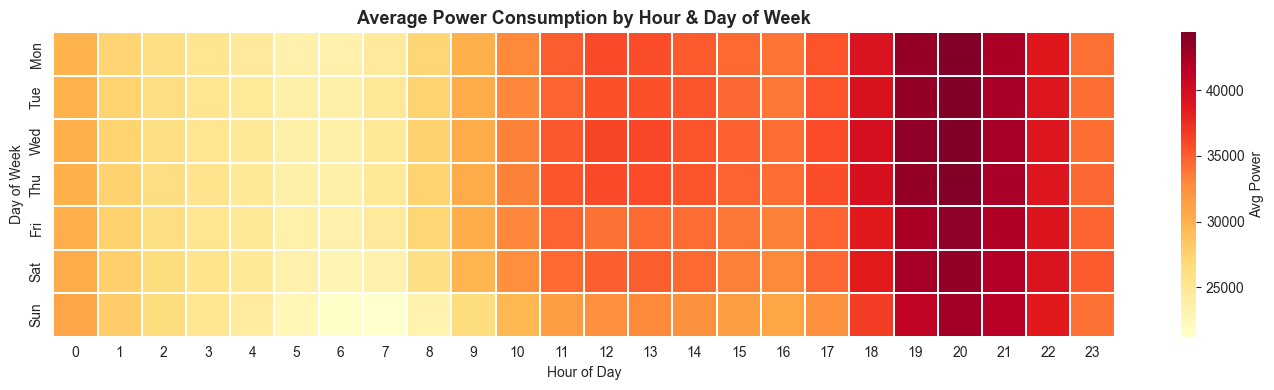

In [9]:
# Add time features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek  # 0=Monday

pivot = df.groupby(['dayofweek', 'hour'])['Zone 1 Power Consumption'].mean().unstack()

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.01, yticklabels=day_labels,
            cbar_kws={'label': 'Avg Power'})
plt.title('Average Power Consumption by Hour & Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

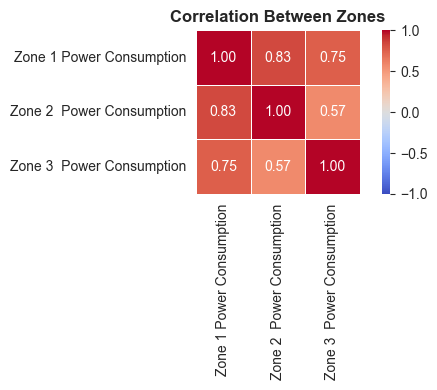

In [10]:
plt.figure(figsize=(6, 4))
corr = df[zones].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Between Zones', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 50)
print("📋 DAY 1 EDA SUMMARY")
print("=" * 50)
print(f"Total records        : {len(df):,}")
print(f"Date range           : {df.index.min().date()} → {df.index.max().date()}")
print(f"Missing values       : {df.isnull().sum().sum()}")
print(f"Anomaly points found : {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")
print(f"Plots saved          : 5 PNG files")
print()
print("✅ Day 1 complete! Move on to Day 2 — Feature Engineering.")

📋 DAY 1 EDA SUMMARY
Total records        : 52,416
Date range           : 2017-01-01 → 2017-12-30
Missing values       : 0
Anomaly points found : 0 (0.00%)
Plots saved          : 5 PNG files

✅ Day 1 complete! Move on to Day 2 — Feature Engineering.
